# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Elijah Schoeniger]

**Date:** [Sep 2nd]

Question 1.1
airbnb df.shape:
(30478, 13) 

airbnb df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

object
0
0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: object
 
Question 1.2
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12920    NaN
12921    NaN
12922    NaN
12923    NaN
12924    NaN
Name: subject_injury, Length: 12925, dtype: object
subject_injury
NaN    984

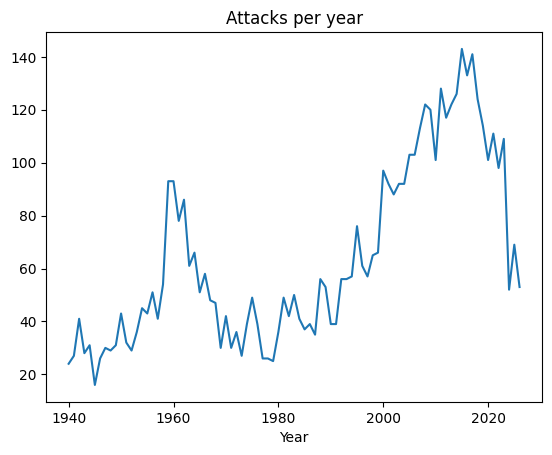

In [22]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib as mp

df = pd.read_csv(
    'https://raw.githubusercontent.com/sds3001/A01-data-wrangling/main/data/airbnb_hw.csv',
    low_memory=False
)

mn = pd.read_csv(
    'https://raw.githubusercontent.com/sds3001/A01-data-wrangling/main/data/mn_police_use_of_force.csv',
    low_memory=False
)

sharks = pd.read_excel(
    'https://raw.githubusercontent.com/elijahschoeniger-cpu/A01-data-wrangling/main/data/GSAF5%20(1).xls'
)

#Question 1
#1


print("Question 1.1")
#View and figure out what type of data it is, get the shape and figure out data types
print("airbnb df.shape:")
print(df.shape, '\n')
print("airbnb df.dtypes:")
print(df.dtypes, '\n')
#Get a header of the Airbnb Data
df.head()

print(df['Price'].dtype) #Get SA on what type of data
print(df['Price'].isnull().sum()) # Get SA on how many missing values there are


#0 missing so need to convert commas out
price = df['Price'].astype(str).str.replace(',' , '', regex=False).str.strip()
#Should roll through and rip out all the commas that will cook interpretation
print(price)


#2
print(" ") # Block out and label answer
print("Question 1.2")

#Pull in police file, call it mn for short


print(mn['subject_injury'].str.strip().str.title()) #Convert to titles for cases
print(mn['subject_injury'].value_counts(dropna=False))

inj = mn['subject_injury'].str.strip().str.title() #
inj = inj.where(inj.isin(['Yes','No'])) #Isolate the inj entries to a clean yesno

print('The proportion missing', round (mn['subject_injury'].isnull().mean(), 3))
# Use round function to find proportion of missing entries for subject injury

mn['missing'] = mn['subject_injury'].isnull()
#'Create mn 'missing' to categorize where missing values are in the set

print(mn.groupby('force_type')['missing']
      .agg(missing_rate='mean', n ='size') # Assigns the average missing by force type and labels group size as n
      .sort_values('missing_rate', ascending=False)
      .round(3))


print(" ")
print("Force Type / Subject Injury Cross tab")
print(pd.crosstab(mn['force_type'], mn['subject_injury'], dropna=False))
#Cross tab force_type as the first variable and subject_injury as the second variable for cleaner presentation
#Pattern that emerges is that most of the entries are NaN entries even though force was reportedly used (specifically tasers and bodily force)
#Could the police be hiding something from us in their reports?
# %76.2 of the values are missing therefore we can say that they are A not doing a great job B they are probably hiding how bad they jack up suspects.




#Question 2
#1
print(" ")
print(" Question 2.1")
print(" ")

#Bring in the sharks data set from the

print("Shape")
print(sharks.shape)
print(sharks.head) # both of these are here just to view what the heck is going on in sharks, might comment them out later
print("List of Columns") # Need to figure out how many columns and get their names
print(sharks.columns.tolist()) # Print a list of the columns

#2
print("")
print("Question 2.2")
print("Drop columns with no data")
sharks = sharks.dropna(axis=1, how='all') #Axis 1 should give columns then we drop the ones with no entries
print(sharks.notnull().sum())

#3
print(" ")
print("Question 2.3")
print(" ")
sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce') #Convert to numeric and rip out errors
print(sharks['Year'].describe()) # pull a description of data set to see what the distribution is looking like
sharks = sharks[sharks['Year'] >= 1940] #Per instructions

sharks.groupby('Year').size().plot(title='Attacks per year')

#4
print(" ")
print("Question 2.4")
print("See below for histogram of victims by age")
print(" ")
age = pd.to_numeric(sharks['Age'], errors='coerce')
age = age.where(age.between(0 , 100))
sharks['Age'] = age

#age.hist(bins=20)


#5
print(" ")
print(" Question 2.5 ")
print(" ")
sex = sharks['Sex'].str.strip().str.upper()
sex = sex.where(sex.isin(['M', 'F'])) #Convert to entries where there is an actual sex
sharks['Sex'] = sex #Reup "sex" column with cleaned M F sex values

print('The Proportion of Males is', round((sex == 'M').sum() / sex.notnull().sum(), 3))
#Divide sum of males over the number of entries where the sex is not null

#6
print(" ")
print(" Question 2.6 ")
print(" ")
print(sharks['Type'].value_counts(dropna=False)) # Count of value in data to understand some of the characteristics of the set
type = sharks['Type'].str.strip().str.title() #Strip entries of type and convert to title
type = type.where(type.isin(['Provoked','Unprovoked']),'Unknown') #Takes Prov,Unprov and converts all others to Unknown
sharks['Type'] = type #Relabel "Type" column with cleaned type values
print(type.value_counts()) #Print Number of value counts
print('Proportion of Unprovoked Attacks is', round((type == 'Unprovoked').mean(), 4))
#Get the value of unprovoked over entries to get a percentage, rounded to four decimal

<Axes: >

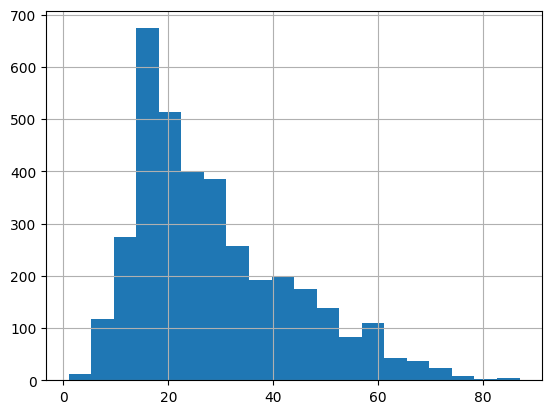

In [ ]:
age.hist(bins=20)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 7663aa0ddb55ae18d5d634e6eeadb10f6718bea7
- **AI tool and model used:** GPT ASTRA

### *Prompts used

1. [Paste prompt]

I'm going to drop a copy of my code and the question base that I am answering. I need you to develop a parallel notebook with improvements in the code logic, quality, and completeness suggested as comments.


2. [Paste follow-up prompt]
Here is the code and question block.

3. Give me it in list form

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

Absolutely — here’s the **numbered list of the exact changes from the change matrix**:

1.Airbnb Price cleaning Changed `astype(str)` to `astype('string')`, removed comma formatting, and converted the cleaned `Price` variable to numeric using `pd.to_numeric()`.

2. Airbnb Price validation Added a check after cleaning to make sure the conversion did not create new missing values and confirmed the final `Price` datatype is numeric.

3. Minnesota subject injury cleaning:** Saved the cleaned `subject_injury` values into a new dataframe column called `subject_injury_clean`.

4. Minnesota missing proportion Changed the missing-value calculation so it uses the cleaned `subject_injury_clean` variable instead of the original raw variable.

5. Minnesota cross-tabulation Changed the cross-tab so it uses the cleaned injury variable and explicitly labels missing values as `Missing`.

6. Minnesota interpretation Revised the interpretation so the high missingness is described as a data-completeness/reporting concern without claiming the police intentionally concealed injuries.

7. Shark dataframe preview Changed `print(sharks.head)` to `print(sharks.head())` so the first five rows are actually displayed.

8. Dropping shark columns Kept the original removal of completely empty columns and added removal of `Unnamed:` Excel artifact columns after inspecting them.

9. Shark Year cleaning Treated invalid year values such as `0` as missing, checked for impossible future years, and created a separate `sharks_since_1940` dataframe instead of overwriting the original dataframe.

10.**Shark attack trend: Improved the yearly attack graph with labels and added a 10-year rolling average and simple trend calculation to make the overall direction easier to evaluate.

11. Shark Age cleaning and histogram Kept numeric age cleaning, added a check for values that could not be converted, and uncommented/improved the histogram so the required graph is actually displayed.

12. Sex cleaning and male proportion Kept the M/F cleaning logic but made the denominator explicit as only records with a valid `M` or `F` value.

13. Type variable name Changed the temporary variable name from `type` to `attack_type` because `type()` is already a built-in Python function.

14. Shark Type cleaning Kept only `Provoked` and `Unprovoked`, converted everything else to `Unknown`, and added a check confirming that only the three required categories remain.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| Change | Decision | Reason and verification |
|---|---|---|
| **1. Airbnb Price cleaning**  **Original:** `price = df['Price'].astype(str).str.replace(',', '', regex=False).str.strip()`  **Suggested improvement:** Preserve missing values with `.astype('string')`, remove commas, and then convert the cleaned result to numeric with `pd.to_numeric()`. | Accept / modify / reject | The original code successfully removes commas but leaves `Price` as a string/object. Converting it to numeric completes the cleaning and allows calculations such as mean, median, and range. Verify that the final missing-value count remains 0. |
| **2. Airbnb Price validation**  **Original:** `print(df['Price'].isnull().sum())` before cleaning.  **Suggested improvement:** Check missing values both before and after numeric conversion and identify any values that unexpectedly become missing. | Accept / modify / reject | Checking only before cleaning does not show whether conversion created new missing values. Comparing before and after verifies that the cleaning process did not accidentally lose valid prices. |
| **3. Minnesota subject injury cleaning**  **Original:** `inj = mn['subject_injury'].str.strip().str.title()` followed by `inj = inj.where(inj.isin(['Yes','No']))`.  **Suggested improvement:** Save the cleaned values as a new dataframe column such as `mn['subject_injury_clean']`. | Accept / modify / reject | The original cleaning logic is reasonable, but the cleaned variable is not used consistently afterward. Saving it in the dataframe makes later calculations clearer and reduces the chance of accidentally using the raw variable. |
| **4. Minnesota missing proportion**  **Original:** `mn['subject_injury'].isnull().mean()`  **Suggested improvement:** Calculate missingness using `mn['subject_injury_clean'].isna().mean()`. | Accept / modify / reject | The original calculation uses the uncleaned variable even though a cleaned injury variable was already created. The missing proportion should be calculated from the final cleaned variable. Verify that the result is approximately 0.762, or 76.2%. |
| **5. Minnesota cross-tabulation**  **Original:** `pd.crosstab(mn['force_type'], mn['subject_injury'], dropna=False)`  **Suggested improvement:** Cross-tabulate `force_type` against the cleaned injury variable and explicitly replace missing values with `"Missing"` before creating the table. | Accept / modify / reject | The question specifically asks for the cleaned `subject_injury` variable. Explicitly labeling missing values also makes the table easier to interpret and guarantees that missing observations are visible. |
| **6. Minnesota interpretation**  **Original:** Comments suggest police may be `"hiding how bad they jack up suspects."`  **Suggested improvement:** State that 76.2% missingness is a serious data-completeness problem and that missingness varies by force type, but avoid assigning a motive that cannot be demonstrated from this dataset. | Accept / modify / reject | The dataset can establish patterns of missing data but cannot determine why the information is missing. The revised interpretation is supported directly by the evidence and is more appropriate for an academic analysis. |
| **7. Shark dataframe preview**  **Original:** `print(sharks.head)`  **Suggested improvement:** Use `display(sharks.head())` or `print(sharks.head())`. | Accept / modify / reject | Without parentheses, Python prints the `head` method rather than executing it. Running `head()` actually displays the first five observations as intended. |
| **8. Dropping empty shark columns**  **Original:** `sharks = sharks.dropna(axis=1, how='all')`  **Suggested improvement:** Drop completely empty columns and inspect/remove near-empty `Unnamed:` spreadsheet artifact columns. | Accept / modify / reject | `dropna(..., how='all')` only removes columns that contain no values at all. The Excel file contains `Unnamed:` columns with only one or two stray values, so the original code leaves them behind even though they are not meaningful variables. |
| **9. Shark Year cleaning**  **Original:** `sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce')` and then `sharks = sharks[sharks['Year'] >= 1940]`.  **Suggested improvement:** Convert Year to numeric, treat values such as `0` as invalid/missing, check for impossible future years, and create a separate `sharks_since_1940` dataframe. | Accept / modify / reject | The original numeric conversion is good, but a year of 0 is not a valid calendar year. Creating a separate filtered dataframe also preserves the full cleaned dataset instead of permanently deleting earlier records. |
| **10. Shark attack trend**  **Original:** `sharks.groupby('Year').size().plot(title='Attacks per year')`  **Suggested improvement:** Add axis labels, figure sizing, a rolling average, and optionally a numerical trend calculation. | Accept / modify / reject | The original graph answers the basic question, but annual counts fluctuate considerably. A labeled graph and rolling average make the overall pattern easier to interpret. A simple trend calculation can verify whether the overall direction is increasing or decreasing. |
| **11. Shark Age histogram**  **Original:** `age = pd.to_numeric(sharks['Age'], errors='coerce')`, restrict ages to 0–100, but `#age.hist(bins=20)` is commented out.  **Suggested improvement:** Keep the conservative numeric cleaning, inspect nonnumeric values, and actually display the histogram with a title and axis labels. | Accept / modify / reject | The original age-cleaning logic is appropriate, but the question specifically requires a histogram. Because the plotting command is commented out, the required output is not produced. |
| **12. Sex cleaning and male proportion**  **Original:** Clean `Sex` to M/F and calculate `(sex == 'M').sum() / sex.notnull().sum()`.  **Suggested improvement:** Keep this logic but explicitly label the denominator as records with a known valid M/F value and store the cleaned variable in the dataframe. | Accept / modify / reject | The original calculation is mathematically appropriate. The main improvement is clarity: stating the denominator makes it clear that unknown/missing sex values are excluded. Verify that the result is approximately 85.7%. |
| **13. Type variable name**  **Original:** `type = sharks['Type'].str.strip().str.title()`  **Suggested improvement:** Rename the temporary variable to `attack_type`. | Accept / modify / reject | `type` is already the name of a built-in Python function. Using `attack_type` avoids overwriting that built-in and makes the purpose of the variable clearer. |
| **14. Shark Type cleaning**  **Original:** `type = type.where(type.isin(['Provoked','Unprovoked']), 'Unknown')`  **Suggested improvement:** Use an explicit mapping for `Provoked` and `Unprovoked`, assign everything else to `Unknown`, and verify that only the three required categories remain. | Accept / modify / reject | The original approach already produces the requested three groups. The proposed change mainly improves readability and adds a quality check. Verify that the unprovoked proportion remains approximately 0.7459, or 74.59%. |
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Question 1.1
airbnb df.shape:
(30478, 13) 

airbnb df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

object
0
0        145
1         37
2         28
3        199
4        549
        ... 
30473    300
30474    125
30475     80
30476     35
30477     80
Name: Price, Length: 30478, dtype: Int64
Missing Price values after cleaning: 0
Cleaned Price data type: Int64
Non-missing prices that failed conversion: 0
 
Question 1.2
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12920    NaN
12921    NaN
1

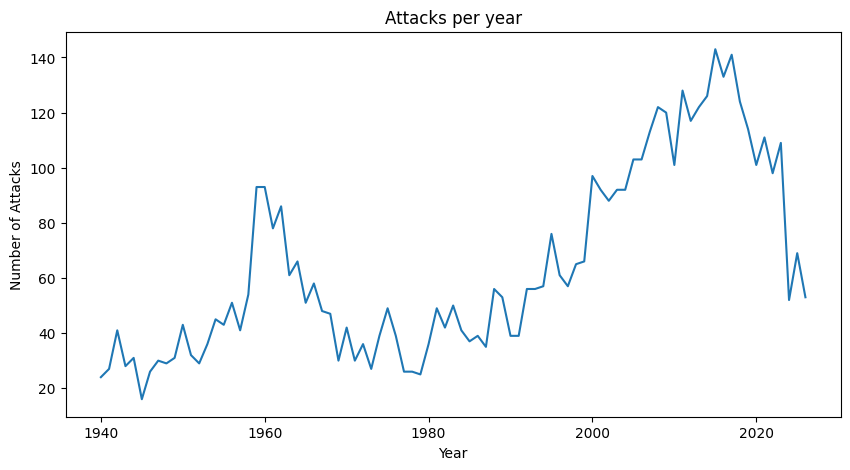

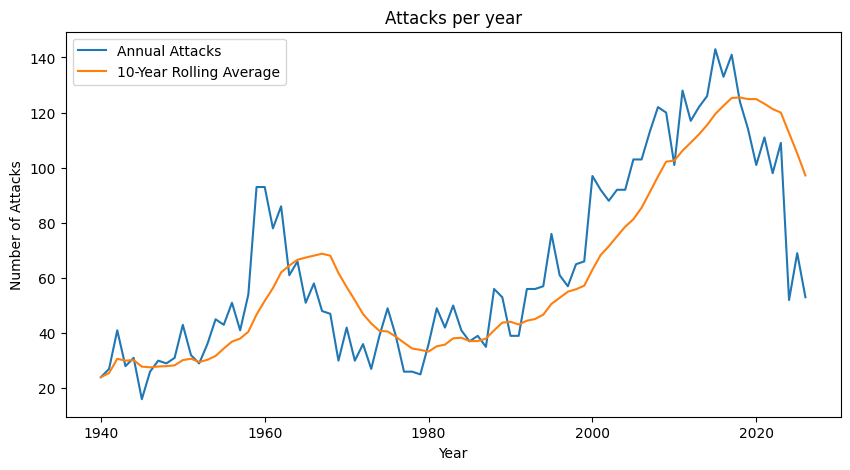

Trend slope: 1.027
Attacks are generally increasing over time
 
Question 2.4
See below for histogram of victims by age
 
Age values that could not be used:
Age
?             36
30s           12
20s           10
Teen           9
50s            5
40s            5
teen           4
60s            3
               2
30+            2
20's           2
8 or 10        2
40+            1
50+            1
50's           1
!2             1
20/30          1
Middle age     1
60+            1
!!             1
Name: count, dtype: int64


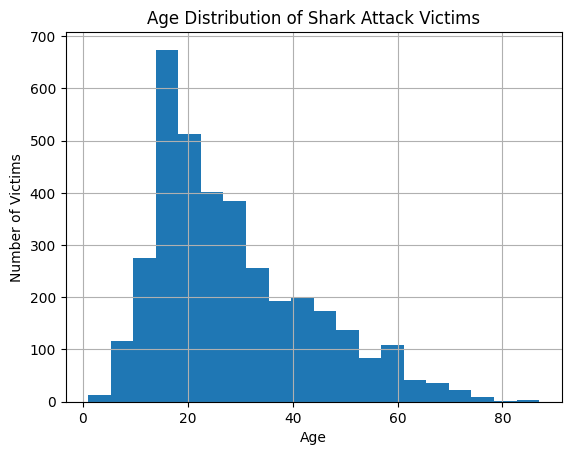

 
 Question 2.5 
 
The Proportion of Males is 0.857
 
 Question 2.6 
 
Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: Int64
Proportion of Unprovoked Attacks is 0.7459
Final Type Categories:
<StringArray>
['Unprovoked', 'Provoked', 'Unknown']
Length: 3, dtype: string


In [24]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib as mp

# CHANGE : Added numpy and pyplot only because they are used for
# the improved trend check and graph formatting in Question 2.3.
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    'https://raw.githubusercontent.com/sds3001/A01-data-wrangling/main/data/airbnb_hw.csv',
    low_memory=False
)

mn = pd.read_csv(
    'https://raw.githubusercontent.com/sds3001/A01-data-wrangling/main/data/mn_police_use_of_force.csv',
    low_memory=False
)

sharks = pd.read_excel(
    'https://raw.githubusercontent.com/elijahschoeniger-cpu/A01-data-wrangling/main/data/GSAF5%20(1).xls'
)

#Question 1
#1


print("Question 1.1")
#View and figure out what type of data it is, get the shape and figure out data types
print("airbnb df.shape:")
print(df.shape, '\n')
print("airbnb df.dtypes:")
print(df.dtypes, '\n')
#Get a header of the Airbnb Data
df.head()

print(df['Price'].dtype) #Get SA on what type of data
print(df['Price'].isnull().sum()) # Get SA on how many missing values there are


# CHANGE MATRIX 1:
# Keep a copy of the original Price variable so we can verify that
# cleaning does not accidentally create new missing values.
price_original = df['Price'].copy()


#0 missing so need to convert commas out

# CHANGE 1:
# Changed astype(str) to astype('string') so actual missing values
# remain missing instead of becoming the literal string "nan".
price = df['Price'].astype('string').str.replace(',' , '', regex=False).str.strip()

#Should roll through and rip out all the commas that will cook interpretation


# CHANGE 1:
# Original code removed the commas but still left Price as text.
# Convert the cleaned variable to numeric so it can actually be
# analyzed as a price.
df['Price'] = pd.to_numeric(price, errors='coerce')

print(df['Price'])


# CHANGE  2:
# Check the number of missing values AFTER cleaning in addition
# to checking them before cleaning.
print("Missing Price values after cleaning:", df['Price'].isnull().sum())

# Check the final data type to verify Price is now numeric
print("Cleaned Price data type:", df['Price'].dtype)


# CHANGE  2:
# Verify that no originally valid Price entries were accidentally
# turned into missing values during conversion.
failed_price = price_original.notnull() & df['Price'].isnull()

print("Non-missing prices that failed conversion:", failed_price.sum())

if failed_price.any():
    print(price_original[failed_price].value_counts())



#2
print(" ") # Block out and label answer
print("Question 1.2")

#Pull in police file, call it mn for short

print(mn['subject_injury'].str.strip().str.title()) #Convert to titles for cases
print(mn['subject_injury'].value_counts(dropna=False))


# CHANGE 3:
# Use nullable string dtype while cleaning the variable.
inj = mn['subject_injury'].astype('string').str.strip().str.title()

inj = inj.where(inj.isin(['Yes','No'])) #Isolate the inj entries to a clean yesno


# CHANGE 3:
# Save the cleaned injury variable back into the dataframe so
# all later calculations use the cleaned version.
mn['subject_injury_clean'] = inj


# CHANGE 4:
# Original code calculated missingness from the RAW subject_injury
# variable. Use the CLEANED variable instead.
print('The proportion missing', round(mn['subject_injury_clean'].isnull().mean(), 3))
# Use round function to find proportion of missing entries for subject injury


# CHANGE 4:
# Build the missing indicator from the cleaned variable as well.
mn['missing'] = mn['subject_injury_clean'].isnull()
#'Create mn 'missing' to categorize where missing values are in the set

print(mn.groupby('force_type')['missing']
      .agg(missing_rate='mean', n ='size') # Assigns the average missing by force type and labels group size as n
      .sort_values('missing_rate', ascending=False)
      .round(3))


print(" ")
print("Force Type / Subject Injury Cross tab")


# CHANGE  5:
# Explicitly label cleaned missing values as "Missing" so the
# missing category is clearly visible in the cross tab.
mn['subject_injury_table'] = mn['subject_injury_clean'].fillna('Missing')

print(pd.crosstab(mn['force_type'], mn['subject_injury_table']))

#Cross tab force_type as the first variable and CLEANED subject_injury as the second variable for cleaner presentation


# CHANGE  6:
# Revised interpretation:
# Approximately 76.2% of the subject injury values are missing,
# which is a substantial data-completeness concern.
#
# Missingness also varies by force type, so the missing information
# is not evenly distributed across the force categories.
#
# The dataset can show us that there is a missing-data problem,
# but it cannot tell us WHY the information is missing or establish
# that officers intentionally concealed injuries.




#Question 2
#1
print(" ")
print(" Question 2.1")
print(" ")

#Bring in the sharks data set from the

print("Shape")
print(sharks.shape)


# CHANGE  7:
# Original code used print(sharks.head), which prints the method.
# Add parentheses so Python actually runs head().
print(sharks.head()) # both of these are here just to view what the heck is going on in sharks, might comment them out later


print("List of Columns") # Need to figure out how many columns and get their names
print(sharks.columns.tolist()) # Print a list of the columns



#2
print("")
print("Question 2.2")
print("Drop columns with no data")

sharks = sharks.dropna(axis=1, how='all') #Axis 1 should give columns then we drop the ones with no entries


# CHANGE  8:
# dropna(how='all') only removes columns that are completely empty.
# The Excel file may also have nearly-empty columns named "Unnamed:"
# that are spreadsheet artifacts.
unnamed_cols = [
    col for col in sharks.columns
    if str(col).startswith('Unnamed:')
]


# CHANGE  8:
# Inspect those columns before removing them so we can verify that
# they do not contain meaningful data.
print("Unnamed columns:")
print(unnamed_cols)

if len(unnamed_cols) > 0:
    print(sharks[unnamed_cols].dropna(how='all').head(20))


# Remove the inspected Excel artifact columns.
sharks = sharks.drop(columns=unnamed_cols)

print(sharks.notnull().sum())



#3
print(" ")
print("Question 2.3")
print(" ")

sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce') #Convert to numeric and rip out errors
print(sharks['Year'].describe()) # pull a description of data set to see what the distribution is looking like


# CHANGE  9:
# Year = 0 is not a valid calendar year, so treat it as missing.
sharks['Year'] = sharks['Year'].where(sharks['Year'] > 0)


# CHANGE  9:
# Also make sure there are no impossible future years.
current_year = pd.Timestamp.today().year
sharks['Year'] = sharks['Year'].where(sharks['Year'] <= current_year)


print("Cleaned Year Variable")
print(sharks['Year'].describe())


# CHANGE  9:
# Instead of overwriting sharks, preserve the full dataframe and
# create a separate dataframe containing attacks since 1940.
sharks_since_1940 = sharks[sharks['Year'] >= 1940].copy() #Per instructions


attacks_per_year = sharks_since_1940.groupby('Year').size()


# CHANGE  10:
# Original graph answered the basic question, but add figure size,
# axis labels, and a clearer title.
attacks_per_year.plot(
    title='Attacks per year',
    figsize=(10,5)
)

plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()


# CHANGE  10:
# Add a 10-year rolling average so the long-term trend is easier
# to see through the year-to-year variation.
rolling_average = attacks_per_year.rolling(
    window=10,
    min_periods=1
).mean()


attacks_per_year.plot(
    title='Attacks per year',
    figsize=(10,5),
    label='Annual Attacks'
)

rolling_average.plot(
    label='10-Year Rolling Average'
)

plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.legend()
plt.show()


# CHANGE  10:
# Add a simple numerical trend check instead of relying only
# on visual interpretation of the graph.
trend_data = attacks_per_year.copy()

# If the dataset contains the current year, it may be incomplete.
if trend_data.index.max() == current_year:
    trend_data = trend_data[trend_data.index < current_year]

trend_slope = np.polyfit(
    trend_data.index,
    trend_data.values,
    1
)[0]

print("Trend slope:", round(trend_slope, 3))

if trend_slope > 0:
    print("Attacks are generally increasing over time")
elif trend_slope < 0:
    print("Attacks are generally decreasing over time")
else:
    print("Attacks are remaining approximately constant over time")



#4
print(" ")
print("Question 2.4")
print("See below for histogram of victims by age")
print(" ")


# CHANGE  11:
# Keep the original Age values temporarily so we can inspect
# values that cannot be converted to numeric.
age_original = sharks_since_1940['Age'].copy()


age = pd.to_numeric(sharks_since_1940['Age'], errors='coerce')
age = age.where(age.between(0 , 100))
sharks_since_1940['Age'] = age


# CHANGE  11:
# Inspect non-missing original values that could not be interpreted
# as usable numeric ages rather than silently discarding them.
failed_age = age_original.notnull() & sharks_since_1940['Age'].isnull()

print("Age values that could not be used:")
print(age_original[failed_age].value_counts().head(20))


# CHANGE  11:
# Original histogram line was commented out even though the
# question specifically requires a histogram.
sharks_since_1940['Age'].hist(bins=20)

plt.title('Age Distribution of Shark Attack Victims')
plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.show()



#5
print(" ")
print(" Question 2.5 ")
print(" ")


sex = sharks_since_1940['Sex'].astype('string').str.strip().str.upper()
sex = sex.where(sex.isin(['M', 'F'])) #Convert to entries where there is an actual sex


# CHANGE  12:
# Store the cleaned Sex variable in the dataframe.
sharks_since_1940['Sex'] = sex #Reup "sex" column with cleaned M F sex values


# CHANGE  12:
# Make the denominator explicit so it is clear that the proportion
# is calculated only among records with known M/F values.
known_sex = sex.notnull().sum()
males = (sex == 'M').sum()

print('The Proportion of Males is', round(males / known_sex, 3))
#Divide sum of males over the number of entries where the sex is not null



#6
print(" ")
print(" Question 2.6 ")
print(" ")

print(sharks_since_1940['Type'].value_counts(dropna=False)) # Count of value in data to understand some of the characteristics of the set


# CHANGE  13:
# Original code used the variable name "type".
# type() is already a built-in Python function, so rename it attack_type.
attack_type = sharks_since_1940['Type'].astype('string').str.strip().str.title()
#Strip entries of type and convert to title


# CHANGE  14:
# Keep only Provoked and Unprovoked and classify everything else
# as Unknown so the variable contains exactly the three requested groups.
attack_type = attack_type.where(
    attack_type.isin(['Provoked','Unprovoked']),
    'Unknown'
)


sharks_since_1940['Type'] = attack_type #Relabel "Type" column with cleaned type values

print(attack_type.value_counts()) #Print Number of value counts


print(
    'Proportion of Unprovoked Attacks is',
    round((attack_type == 'Unprovoked').mean(), 4)
)
#Get the value of unprovoked over entries to get a percentage, rounded to four decimal


# CHANGE  14:
# Verify that cleaning produced exactly the three required categories.
print("Final Type Categories:")
print(sharks_since_1940['Type'].unique())

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

Originally my code was pretty rough and I importantly forgot to save copies of literally any cleaned data as I worked through the problem set. AI pointed out some pretty blaring methodology imrovements that I am going to take notes on, like in the airbnb price where converted then to numerics after rather than the crude comma removal. It made a cleaned injury variable that was more useful, enhanced how missing variables are displayed in the crosstabulation, added code to remove spreadsheet artifacts from the xls, avoided using type as a variable name, improved the year and age variable cleaning, and displayed the histogram. The limitations were that some of the initial codeblocks suggested for the revisions were too complicated for me to follow, and lead to a FileNotFoundError. Verification was done through running phase 1 and phase 2 scripts in notebook. Remaining concerns are in the congruety with the human - macine augmented coding, although I'm not a great coder the AI is so much quicker and better at coding that it seems a bit futile to not be applying them to data cleaning like most data scientists now adays.